# Timepix data reduction @ISIS

In [1]:
import scippnexus as snx
import scipp as sc


def _load_isis_nexus(filename) -> sc.DataArray:
    sample_events = snx.load(
        filename,
        root='entry/instrument/event_mode_detectors/timepix3/timepix3_events',
    )
    sample_events.bins.coords["event_time_zero"] = sc.bins_like(
        sample_events, fill_value=sample_events.coords["event_time_zero"]
    )
    da: sc.DataArray = sample_events.bins.concat().value
    da = da.drop_coords("event_time_zero")
    da.coords["tof"] = da.coords.pop("event_time_offset")
    return da.astype(float)

In [3]:
# From login server, /ess/data/ymir/2024/597001/raw/597001_00011386.hdf
sample_da = _load_isis_nexus("sample_data/597001_00011386.hdf")
sample_da

<scipp.DataArray>
Dimensions: Sizes[event:43392376, ]
Coordinates:
* event_id                    int32        <no unit>  (event)  [537160, 119222, ..., 931270, 701989]
* tof                         int32             [ns]  (event)  [696013, 711116, ..., 38740816, 38744577]
Data:
                            float64         [counts]  (event)  [1, 1, ..., 1, 1]

In [4]:
# From login server, /ess/data/ymir/2024/597001/raw/597001_00011385.hdf
open_beam_da = _load_isis_nexus("sample_data/597001_00011385.hdf")  # Open Beam
open_beam_da

<scipp.DataArray>
Dimensions: Sizes[event:94761986, ]
Coordinates:
* event_id                    int32        <no unit>  (event)  [743151, 498287, ..., 580152, 730514]
* tof                         int32             [ns]  (event)  [256782, 269046, ..., 46554050, 46554679]
Data:
                            float64         [counts]  (event)  [1, 1, ..., 1, 1]

In [5]:
import numpy as np


DEFAULT_RESOLUTION = np.array((1024, 1024))
DEFAULT_TOF_BIN_EDGES = sc.linspace(
    dim='tof', start=100.0, stop=99999999.0, num=101, unit="ns"
)


def _reduce_isis_data(
    da: sc.DataArray,
    virtual_resolution: np.ndarray = DEFAULT_RESOLUTION,
    tof_bin_edges: sc.Variable = DEFAULT_TOF_BIN_EDGES,
    show_result: bool = False,
    background: bool = False,
) -> sc.DataArray:
    image_ids = sc.arange(
        dim='event_id', start=0, stop=virtual_resolution.prod(), unit=None
    )
    arbitrary_x_coord = sc.arange(dim='x', start=0, stop=virtual_resolution[0])
    arbitrary_y_coord = sc.arange(dim='y', start=0, stop=virtual_resolution[1])
    reduced = (
        da.bin(tof=tof_bin_edges)
        .group(image_ids)
        .hist()
        .fold(dim='event_id', dims=['x', 'y'], shape=virtual_resolution)
    )
    reduced.coords.update({"x": arbitrary_x_coord, "y": arbitrary_y_coord})
    reduced.coords.pop("event_id")
    if show_result:
        display(reduced)
    if background:
        from ess.imaging.normalize import apply_threshold_to_background_image

        reduced.name = "OpenBeam"
        reduced = apply_threshold_to_background_image(
            reduced, background_threshold=sc.scalar(1.0, unit="counts")
        )
    else:
        from ess.imaging.normalize import apply_threshold_to_sample_images

        reduced.name = "Sample"
        reduced = apply_threshold_to_sample_images(
            reduced, sample_threshold=sc.scalar(0.0, unit="counts")
        )
    # We're adding variances after reduction since some zeros are removed
    reduced.data.variances = reduced.data.values
    return reduced


In [6]:
reduced_sample = _reduce_isis_data(sample_da, show_result=True)
reduced_ob = _reduce_isis_data(open_beam_da, show_result=True, background=True)
normalized = reduced_sample / reduced_ob
normalized.name = "Normalized"
normalized

<scipp.DataArray>
Dimensions: Sizes[tof:100, x:1024, y:1024, ]
Coordinates:
* tof                       float64             [ns]  (tof [bin-edge])  [100, 1.0001e+06, ..., 9.9e+07, 1e+08]
* x                           int64  [dimensionless]  (x)  [0, 1, ..., 1022, 1023]
* y                           int64  [dimensionless]  (y)  [0, 1, ..., 1022, 1023]
Data:
                            float64         [counts]  (tof, x, y)  [0, 0, ..., 0, 0]

<scipp.DataArray>
Dimensions: Sizes[tof:100, x:1024, y:1024, ]
Coordinates:
* tof                       float64             [ns]  (tof [bin-edge])  [100, 1.0001e+06, ..., 9.9e+07, 1e+08]
* x                           int64  [dimensionless]  (x)  [0, 1, ..., 1022, 1023]
* y                           int64  [dimensionless]  (y)  [0, 1, ..., 1022, 1023]
Data:
                            float64         [counts]  (tof, x, y)  [0, 0, ..., 0, 0]

<scipp.DataArray>
Dimensions: Sizes[tof:100, x:1024, y:1024, ]
Coordinates:
* tof                       float64             [ns]  (tof [bin-edge])  [100, 1.0001e+06, ..., 9.9e+07, 1e+08]
* x                           int64  [dimensionless]  (x)  [0, 1, ..., 1022, 1023]
* y                           int64  [dimensionless]  (y)  [0, 1, ..., 1022, 1023]
Data:
  Normalized                float64  [dimensionless]  (tof, x, y)  [0, 0, ..., 0, 0]  [0, 0, ..., 0, 0]

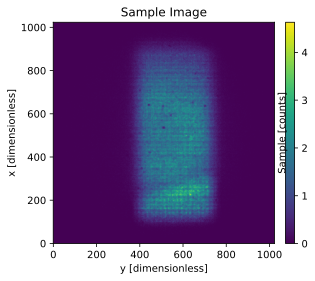

In [7]:
reduced_sample.mean('tof').plot(aspect='equal', title="Sample Image")

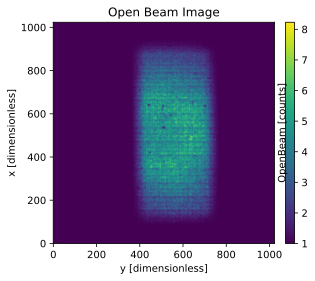

In [8]:
reduced_ob.mean('tof').plot(aspect='equal', title="Open Beam Image")

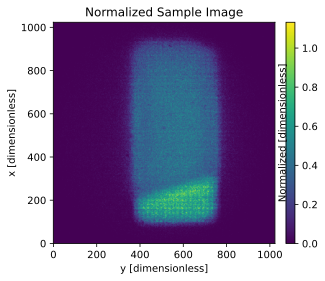

In [9]:
normalized.mean('tof').plot(aspect='equal', title='Normalized Sample Image')

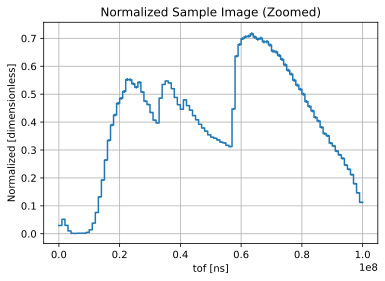

In [10]:
normalized['x', 400:600]['y', 400:600].mean('x').mean('y').plot(
    aspect='equal', title='Normalized Sample Image (Zoomed)', grid=True
)

In [ ]:
import scitiff

scitiff.save_scitiff(
    reduced_sample.rename_dims({'tof': "t"}).astype('float32'), "sample_data/sample.tiff"
)
scitiff.save_scitiff(
    reduced_ob.rename_dims({'tof': "t"}).astype('float32'), "sample_data/open_beam.tiff"
)
scitiff.save_scitiff(
    normalized.rename_dims({'tof': "t"}).astype('float32'), "sample_data/normalized.tiff"
)

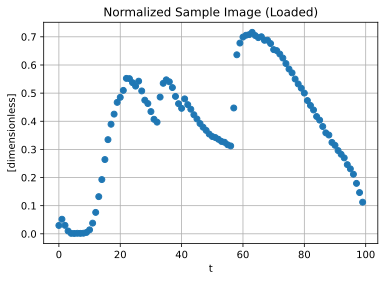

In [ ]:
# Loading
normalized_image_stack = scitiff.load_scitiff("sample_data/normalized.tiff", squeeze=True)
normalized_image_da = normalized_image_stack['image']
normalized_image_da['x', 400:600]['y', 400:600].mean('x').mean('y').plot(
    aspect='equal', title='Normalized Sample Image (Loaded)', grid=True
)

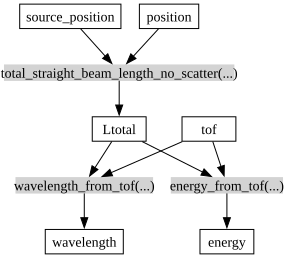

In [13]:
from scippneutron.conversion import graph


PLAIN_GRAPH = {**graph.beamline.beamline(False), **graph.tof.kinematic("tof")}
sc.show_graph(PLAIN_GRAPH)

In [14]:
# Apparently it is about 56 meters?
normalized.coords['Ltotal'] = sc.scalar(56.0, unit='m')
wavelength_transformed = normalized.transform_coords('wavelength', graph=PLAIN_GRAPH)

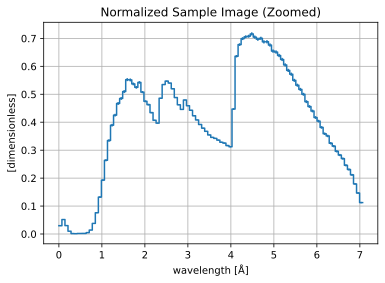

In [15]:
wavelength_transformed['x', 400:600]['y', 400:600].mean('x').mean('y').plot(
    aspect='equal', title='Normalized Sample Image (Zoomed)', grid=True
)

In [16]:
lower_bound = 1.5 * sc.Unit('Å')
upper_bound = 5.0 * sc.Unit('Å')

In [17]:
region = wavelength_transformed['x', 400:600]['y', 400:600]
spectrum = region.mean('x').mean('y')
sliced_spectrum = spectrum['wavelength', lower_bound:upper_bound]

In [18]:
wavelengths = sc.midpoints(sliced_spectrum.coords['wavelength']).values
transmissions = sliced_spectrum.values
transmissions_variances = sliced_spectrum.variances

## Physical model with Ncrystal

## Inspecting the model

In [19]:
import NCrystal
import NCrystal.plot
import matplotlib.pyplot as plt
import numpy as np

In [20]:
# We initalize the model
mat = NCrystal.NCMATComposer()

In [21]:
# We set the model parameters to Iron (slightly off on purpose)
mat.set_cellsg_cubic(2.90)
mat.set_atompos([   ('Fe',0,0,0),
                    ('Fe',0.5, 0.5, 0.5),
                    ])
mat.set_dyninfo_debyetemp("Fe", debye_temp=356)
mat.set_default_temperature(250)
mat.refine_crystal_structure(quiet=True)

In [22]:
scatter = mat.load(#cfg_params="comp=inelas"
                    )

----------------------------------------------------------------------------------------------------
------------------------------------   NCrystal Material Info   ------------------------------------
----------------------------------------------------------------------------------------------------
Data source: <anonymous-ncmat-data>
----------------------------------------------------------------------------------------------------
Density : 7.60478 g/cm3, 0.0820042 atoms/Aa^3
----------------------------------------------------------------------------------------------------
Composition (by mole): 100% Fe
----------------------------------------------------------------------------------------------------
Composition (by mass): 100% Fe
----------------------------------------------------------------------------------------------------
Atom data:
   Fe = Fe(cohSL=9.45fm cohXS=11.2221barn incXS=0.4barn absXS=2.56barn mass=55.8472u Z=26)
-----------------------------------------------

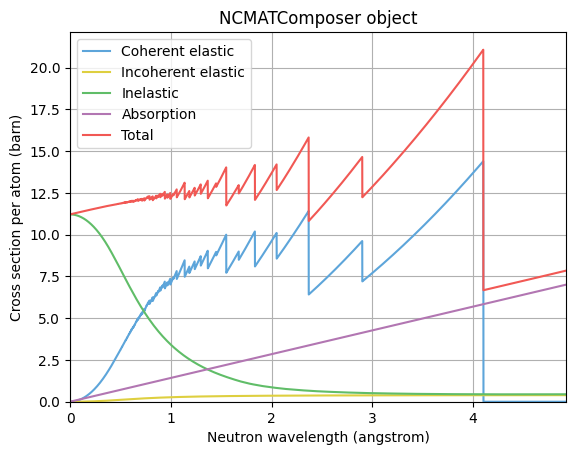

In [24]:
# Information about the model can be viewed with this method
mat.inspect()

In [25]:
# And a short summary can be viewed by printing
print(mat())

NCMAT v7
# Autogenerated by NCMATComposer
#
# Fe (cubic, SG-229)
#
# Atoms per unit cell: 2xFe
#
# NOTICE: crystal structure was verified with spglib to be self-consistent.
#
@CELL
  cubic 2.9
@SPACEGROUP
  229
@ATOMPOSITIONS
  Fe 0 0 0
  Fe 1/2 1/2 1/2
@TEMPERATURE
  default 250
@DYNINFO
  element Fe
  fraction 1
  type vdosdebye
  debye_temp 356



Calculating the simulated spectrum using this model

In [26]:
scatter = mat.load(#cfg_params="comp=inelas"
                    )
absorptions = scatter.absorption.xsect(wl=wavelengths)
scattered = scatter.scatter.xsect(wl=wavelengths)
# Using an arbitrary scale constant of 0.05 to scale cross sections and absorptions. Depends on width of material in a real model.
simulated = np.exp(-0.05*(absorptions+scattered))

### Loading reference Iron slab data from J-PARC

In [27]:
with open('Iron_slab.dat', 'r') as file:
    slab_data = file.readlines()

In [28]:
slab_wavelengths = np.asarray([float(slab_data[i].split("\t")[1]) for i in range(len(slab_data)-1)])
slab_transmissions = np.asarray([float(slab_data[i].split("\t")[2]) for i in range(len(slab_data)-1)])

In [29]:
slab_wavelengths[-1]

np.float64(4.99449)

### Comparing Data sets and initial model

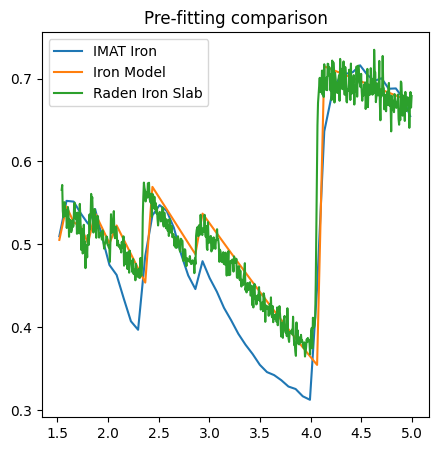

In [31]:
plt.figure(figsize=(5,5))
plt.plot(wavelengths, transmissions, label='IMAT Iron')
#plt.plot(wavelengths, transmissions, label="Data")
plt.plot(wavelengths, simulated, label="Iron Model")
plt.plot(slab_wavelengths, slab_transmissions, label='Raden Iron Slab')
plt.title("Pre-fitting comparison")
plt.legend()
plt.show()

## Bragg-edge fitting with Ncrystal and EasyScience

In [32]:
from easyscience.Objects.variable import Parameter
from easyscience.Objects.ObjectClasses import BaseObj
from easyscience.fitting import Fitter

### Setting up the fitting models

Defining the fitting parameters and their initial values \
We're defining 2 sets of parameters because we want to fit a model to both sets of data

In [33]:
lattice_constant =  Parameter(name="Lattice constant",          value=2.85, unit="angstrom",    min=0,  max=4,    fixed=False)
debye_temperature = Parameter(name="Debye temperature",         value=300,  unit="kelvin",      min=100,  max=800,  fixed=False)
temperature =       Parameter(name="Temperature",               value=300,  unit="kelvin",      min=0,  max=600,  fixed=False)
intensity_scale =   Parameter(name="Intensity scale factor",    value=0.05,                      fixed=False)

In [34]:
lattice_constant_slab =  Parameter(name="Lattice constant",          value=2.85, unit="angstrom",    min=0,  max=4,    fixed=False)
debye_temperature_slab = Parameter(name="Debye temperature",         value=300,  unit="kelvin",      min=100,  max=800,  fixed=False)
temperature_slab =       Parameter(name="Temperature",               value=300,  unit="kelvin",      min=0,  max=600,  fixed=False)
intensity_scale_slab =   Parameter(name="Intensity scale factor",    value=0.05,                      fixed=False)

Defining the fit functions to go into EasyScience

In [35]:
def iron_bragg(wavelength):
    # Initalize the NCrystal material composer
    material = NCrystal.NCMATComposer()
    # Set the material parameters with the fitting variables
    material.set_cellsg_cubic(lattice_constant.value)
    material.set_atompos([  ('Fe',0,0,0),
                            ('Fe',0.5, 0.5, 0.5),
                            ])
    material.set_dyninfo_debyetemp("Fe", debye_temp=debye_temperature.value)
    material.set_default_temperature(temperature.value)

    # Identify the space group from atomic positions
    material.refine_crystal_structure(quiet=True)

    #print("lattice constant:", lattice_constant.value)
    scatter = material.load()

    # Create scattering spectrum
    spectrum = np.exp(-intensity_scale.value*(scatter.scatter.xsect(wl=wavelength) + scatter.absorption.xsect(wl=wavelength)))
    return spectrum

def iron_bragg_slab(wavelength):
    # Initalize the NCrystal material composer
    material = NCrystal.NCMATComposer()
    # Set the material parameters with the fitting variables
    material.set_cellsg_cubic(lattice_constant_slab.value)
    material.set_atompos([  ('Fe',0,0,0),
                            ('Fe',0.5, 0.5, 0.5),
                            ])
    material.set_dyninfo_debyetemp("Fe", debye_temp=debye_temperature_slab.value)
    material.set_default_temperature(temperature_slab.value)

    # Identify the space group from atomic positions
    material.refine_crystal_structure(quiet=True)

    #print("lattice constant:", lattice_constant.value)
    scatter = material.load()

    # Create scattering spectrum
    spectrum = np.exp(-intensity_scale_slab.value*(scatter.scatter.xsect(wl=wavelength) + scatter.absorption.xsect(wl=wavelength)))
    return spectrum

Make the EasyScience container for the fitting parameters

In [36]:
iron_spectrum = BaseObj(
                        name='Iron transmission spectrum', 
                        lattice_constant=lattice_constant, 
                        debye_temperature=debye_temperature,
                        temperature=temperature,
                        intensity_scale=intensity_scale,
                        )
iron_spectrum_slab = BaseObj(
                        name='Iron transmission spectrum slab', 
                        lattice_constant_slab=lattice_constant_slab, 
                        debye_temperature_slab=debye_temperature_slab,
                        temperature_slab=temperature_slab,
                        intensity_scale_slab=intensity_scale_slab,
                        )

Make the EasyScience fitting objects

In [37]:
fitter = Fitter(iron_spectrum, iron_bragg)
fitter_slab = Fitter(iron_spectrum_slab, iron_bragg_slab)

EasyScience can fit data with a variety of different minimizers. To list the available methods, use the "available_minimizers" method:

In [38]:
fitter.available_minimizers

['LMFit',
 'LMFit_leastsq',
 'LMFit_powell',
 'LMFit_cobyla',
 'LMFit_differential_evolution',
 'LMFit_scipy_least_squares',
 'Bumps',
 'Bumps_simplex',
 'Bumps_newton',
 'Bumps_lm',
 'DFO',
 'DFO_leastsq']

For the fits in this notebook, we will use "LMFit_leastsq" which is a standard leastsquares fitting method

In [39]:
fitter.switch_minimizer("LMFit_leastsq")
fitter_slab.switch_minimizer("LMFit_leastsq")

minimizer should be set with enum LMFit_leastsq
minimizer should be set with enum LMFit_leastsq


### Fitting

First we fit the reduced Iron powder data

In [40]:
# Parameters for LMFit_leastsq
results = fitter.fit(x=wavelengths, y=transmissions, 
                     weights=1/np.sqrt(transmissions_variances), 
                     minimizer_kwargs={"epsfcn":0.005,
                                       "ftol":1.49012e-15,
                                       "xtol":1.49012e-15,
                                       },
                    #max_nfev=10000
                     )

Print the fitted values

In [41]:
print(lattice_constant)
print(debye_temperature)
print(temperature)
print(intensity_scale)

<Parameter 'Lattice constant': 2.8962 ± 0.0075 Å, bounds=[0.0:4.0]>
<Parameter 'Debye temperature': 786.4989 ± 2970.5044 K, bounds=[100.0:800.0]>
<Parameter 'Temperature': 597.0128 ± 1542.4093 K, bounds=[0.0:600.0]>
<Parameter 'Intensity scale factor': 0.0577 ± 0.0045, bounds=[-inf:inf]>


We then fit the reference Iron slab data

In [42]:
# Parameters for LMFit_leastsq
results_slab = fitter_slab.fit(x=slab_wavelengths, y=slab_transmissions, 
                     #weights=1/np.sqrt(transmissions_variances), 
                     minimizer_kwargs={"epsfcn":0.005,
                                       "ftol":1.49012e-15,
                                       "xtol":1.49012e-15,
                                       },
                    #max_nfev=10000
                     )

In [43]:
print(lattice_constant_slab)
print(debye_temperature_slab)
print(temperature_slab)
print(intensity_scale_slab)

<Parameter 'Lattice constant': 2.8736 ± 0.0009 Å, bounds=[0.0:4.0]>
<Parameter 'Debye temperature': 296.3930 ± 51.0505 K, bounds=[100.0:800.0]>
<Parameter 'Temperature': 280.3703 ± 68.6234 K, bounds=[0.0:600.0]>
<Parameter 'Intensity scale factor': 0.0508 ± 0.0003, bounds=[-inf:inf]>


### Comparing the fitted models and data

First we need to calculate the spectras with the fitted models

In [44]:
simulated = iron_bragg(wavelengths)
simulated_slab = iron_bragg_slab(slab_wavelengths)

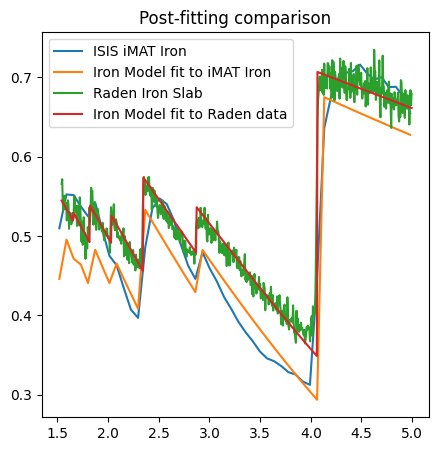

In [45]:
plt.figure(figsize=(5,5))
plt.plot(wavelengths, transmissions, label='ISIS iMAT Iron')
plt.plot(wavelengths, simulated, label="Iron Model fit to iMAT Iron")
plt.plot(slab_wavelengths, slab_transmissions, label="Raden Iron Slab")
plt.plot(slab_wavelengths, simulated_slab, label='Iron Model fit to Raden data')
plt.title("Post-fitting comparison")
plt.legend()
plt.show()